# Analiza fairness modelu ML

**Autor:** Daniel Sadowski, nr indeksu: 259314  
**Temat:** 4 - Analiza fairness modelu ML  
**Kurs:** Aspekty prawne, społeczne i etyczne w AI, PWr 2025/2026

---


## Dataset

In [1]:
import pandas as pd
from sklearn.datasets import fetch_openml

data = fetch_openml(name="adult", version=2, as_frame=True)
df = data.frame

print(f"Kształt: {df.shape}")
print(f"Kolumny: {df.columns.tolist()}")
print(df.head(3))

Kształt: (48842, 15)
Kolumny: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']
   age  workclass  fnlwgt   education  education-num      marital-status  \
0   25    Private  226802        11th              7       Never-married   
1   38    Private   89814     HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951  Assoc-acdm             12  Married-civ-spouse   

          occupation relationship   race   sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black  Male             0             0   
1    Farming-fishing      Husband  White  Male             0             0   
2    Protective-serv      Husband  White  Male             0             0   

   hours-per-week native-country  class  
0              40  United-States  <=50K  
1              50  United-States  <=50K  
2              40  United

## Dataset: Adult Census Income

Zbiór danych pochodzi z US Census Bureau (1994). Zadanie: przewidzieć czy osoba zarabia >50K USD rocznie.

**Atrybuty wrażliwe w tej analizie:**
- `sex` — płeć (Male / Female)
- `race` — rasa (White / Black / Asian-Pac-Islander / Amer-Indian-Eskimo / Other)

**Zmienna docelowa:** `class` — `<=50K` lub `>50K`

Dataset jest standardowym benchmarkiem w badaniach nad fairness w ML. Zawiera 48 842 rekordów i 14 cech.

In [2]:
print("=== Rozkład zmiennej docelowej ===")
print(df["class"].value_counts())
print(f"\nOdsetek >50K: {(df['class'] == '>50K').mean():.1%}")

print("\n=== Rozkład atrybutu: sex ===")
print(df["sex"].value_counts())

print("\n=== Rozkład atrybutu: race ===")
print(df["race"].value_counts())

print("\n=== Brakujące wartości ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

=== Rozkład zmiennej docelowej ===
class
<=50K    37155
>50K     11687
Name: count, dtype: int64

Odsetek >50K: 23.9%

=== Rozkład atrybutu: sex ===
sex
Male      32650
Female    16192
Name: count, dtype: int64

=== Rozkład atrybutu: race ===
race
White                 41762
Black                  4685
Asian-Pac-Islander     1519
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64

=== Brakujące wartości ===
workclass         2799
occupation        2809
native-country     857
dtype: int64


## Eksploracja danych

Poniżej rozkład wyników (`>50K`) w podziale na atrybuty wrażliwe. To punkt wyjścia do analizy — widzimy czy nierówności w danych istnieją *zanim* w ogóle zbudujemy model.

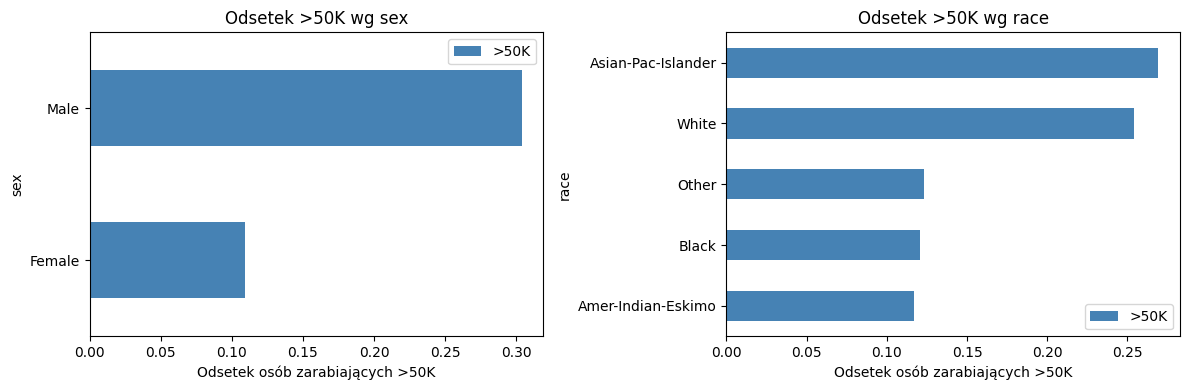

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, atrybut in zip(axes, ["sex", "race"]):
    grupy = df.groupby(atrybut)["class"].value_counts(normalize=True).unstack()
    grupy[">50K"].sort_values().plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"Odsetek >50K wg {atrybut}")
    ax.set_xlabel("Odsetek osób zarabiających >50K")
    ax.legend()

plt.tight_layout()
plt.savefig("../wyniki/eda_grupy_wrazliwe.png", dpi=150, bbox_inches="tight")
plt.show()

## Preprocessing

Kroki przygotowania danych:
1. Usunięcie wierszy z brakami w `workclass` i `occupation` (~6% danych)
2. Binaryzacja `race` → `White` / `Non-White` (pozostałe grupy zbyt małe dla wiarygodnych metryk fairness)
3. Kodowanie zmiennej docelowej: `>50K` → 1, `<=50K` → 0
4. One-hot encoding cech kategorycznych
5. Podział train/test 80/20 ze stratyfikacją

In [4]:
from sklearn.model_selection import train_test_split

df_clean = df.dropna(subset=["workclass", "occupation"]).copy()

df_clean["race_bin"] = df_clean["race"].apply(lambda x: "White" if x == "White" else "Non-White")
df_clean["cel"] = (df_clean["class"] == ">50K").astype(int)

cechy_numeryczne = ["age", "education-num", "hours-per-week", "capital-gain", "capital-loss"]
cechy_kategoryczne = ["workclass", "marital-status", "occupation", "relationship", "native-country"]

X = pd.get_dummies(df_clean[cechy_numeryczne + cechy_kategoryczne], drop_first=True)
y = df_clean["cel"]

atrybut_plec = df_clean["sex"].map({"Male": 1, "Female": 0})
atrybut_rasa = df_clean["race_bin"].map({"White": 1, "Non-White": 0})

X_train, X_test, y_train, y_test, plec_train, plec_test, rasa_train, rasa_test = train_test_split(
    X, y, atrybut_plec, atrybut_rasa,
    test_size=0.2, random_state=42, stratify=y
)

print(f"Zbiór treningowy: {X_train.shape[0]} rekordów")
print(f"Zbiór testowy:    {X_test.shape[0]} rekordów")
print(f"Odsetek >50K (test): {y_test.mean():.1%}")

Zbiór treningowy: 36826 rekordów
Zbiór testowy:    9207 rekordów
Odsetek >50K (test): 24.8%


## Model bazowy — Logistic Regression

Model trenowany bez żadnej świadomości fairness. Służy jako punkt odniesienia — pokażemy że standardowy model optymalizujący dokładność reprodukuje i wzmacnia nierówności obecne w danych.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model_bazowy = LogisticRegression(max_iter=1000, random_state=42)
model_bazowy.fit(X_train, y_train)

y_pred_bazowy = model_bazowy.predict(X_test)

print("=== Model bazowy — metryki klasyczne ===")
print(classification_report(y_test, y_pred_bazowy, target_names=["<=50K", ">50K"]))
print(f"ROC-AUC: {roc_auc_score(y_test, model_bazowy.predict_proba(X_test)[:, 1]):.3f}")

=== Model bazowy — metryki klasyczne ===
              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      6923
        >50K       0.73      0.62      0.67      2284

    accuracy                           0.85      9207
   macro avg       0.81      0.77      0.79      9207
weighted avg       0.84      0.85      0.85      9207

ROC-AUC: 0.902


/home/kretes/miniforge3/envs/AspektyPrawne/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [6]:
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference
from sklearn.metrics import accuracy_score, recall_score, precision_score

def metryki_fairness(y_true, y_pred, atrybut, nazwa_atrybutu):
    mf = MetricFrame(
        metrics={
            "dokładność": accuracy_score,
            "recall": recall_score,
            "precyzja": precision_score,
        },
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=atrybut,
    )
    print(f"\n=== Metryki wg {nazwa_atrybutu} ===")
    print(mf.by_group.round(3))
    dpd = demographic_parity_difference(y_true, y_pred, sensitive_features=atrybut)
    eod = equalized_odds_difference(y_true, y_pred, sensitive_features=atrybut)
    print(f"\nDemographic Parity Difference:  {dpd:.3f}")
    print(f"Equalized Odds Difference:      {eod:.3f}")
    return dpd, eod

print("### PŁEĆ ###")
dpd_plec_baz, eod_plec_baz = metryki_fairness(y_test, y_pred_bazowy, plec_test, "sex")

print("\n### RASA ###")
dpd_rasa_baz, eod_rasa_baz = metryki_fairness(y_test, y_pred_bazowy, rasa_test, "race_bin")

### PŁEĆ ###

=== Metryki wg sex ===
     dokładność  recall  precyzja
sex                              
0         0.922   0.530     0.747
1         0.816   0.638     0.729

Demographic Parity Difference:  0.183
Equalized Odds Difference:      0.108

### RASA ###

=== Metryki wg race_bin ===
          dokładność  recall  precyzja
race_bin                              
0              0.881    0.53     0.612
1              0.845    0.63     0.742

Demographic Parity Difference:  0.096
Equalized Odds Difference:      0.100


## Model z korekcją fairness — ThresholdOptimizer

`ThresholdOptimizer` (fairlearn) działa post-hoc: nie zmienia treningu, lecz dobiera różne progi decyzyjne dla każdej grupy wrażliwej tak, żeby spełnić zadane kryterium fairness.

Trenujemy dwa warianty korekcji:
- `demographic_parity` — wyrównanie odsetka pozytywnych predykcji między grupami
- `equalized_odds` — wyrównanie TPR i FPR między grupami

In [7]:
from fairlearn.postprocessing import ThresholdOptimizer

def trenuj_threshold_optimizer(constraint, atrybut_train, atrybut_test, nazwa):
    model = ThresholdOptimizer(
        estimator=LogisticRegression(max_iter=1000, random_state=42),
        constraints=constraint,
        objective="balanced_accuracy_score",
        predict_method="predict_proba",
    )
    model.fit(X_train, y_train, sensitive_features=atrybut_train)
    y_pred = model.predict(X_test, sensitive_features=atrybut_test)
    print(f"\n{'='*50}")
    print(f"ThresholdOptimizer [{constraint}] — atrybut: {nazwa}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))
    dpd, eod = metryki_fairness(y_test, y_pred, atrybut_test, nazwa)
    return y_pred, dpd, eod

y_pred_dp_plec, dpd_dp_plec, eod_dp_plec = trenuj_threshold_optimizer(
    "demographic_parity", plec_train, plec_test, "sex"
)
y_pred_eo_plec, dpd_eo_plec, eod_eo_plec = trenuj_threshold_optimizer(
    "equalized_odds", plec_train, plec_test, "sex"
)

/home/kretes/miniforge3/envs/AspektyPrawne/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



ThresholdOptimizer [demographic_parity] — atrybut: sex
              precision    recall  f1-score   support

       <=50K       0.91      0.80      0.85      6923
        >50K       0.56      0.77      0.65      2284

    accuracy                           0.79      9207
   macro avg       0.74      0.79      0.75      9207
weighted avg       0.83      0.79      0.80      9207


=== Metryki wg sex ===
     dokładność  recall  precyzja
sex                              
0         0.756   0.930     0.321
1         0.813   0.736     0.679

Demographic Parity Difference:  0.015
Equalized Odds Difference:      0.194


/home/kretes/miniforge3/envs/AspektyPrawne/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



ThresholdOptimizer [equalized_odds] — atrybut: sex
              precision    recall  f1-score   support

       <=50K       0.93      0.74      0.83      6923
        >50K       0.52      0.83      0.64      2284

    accuracy                           0.77      9207
   macro avg       0.72      0.79      0.73      9207
weighted avg       0.83      0.77      0.78      9207


=== Metryki wg sex ===
     dokładność  recall  precyzja
sex                              
0         0.744   0.832     0.297
1         0.776   0.832     0.596

Demographic Parity Difference:  0.093
Equalized Odds Difference:      0.018


## Porównanie modeli

Zestawienie trzech podejść: model bazowy (bez korekcji) vs. dwa warianty ThresholdOptimizer.

                   Accuracy  ROC-AUC  DPD (płeć)  EOD (płeć)
Model                                                       
Bazowy (LR)           0.850    0.902       0.183       0.108
ThresholdOpt [DP]     0.795      NaN       0.015       0.194
ThresholdOpt [EO]     0.766      NaN       0.093       0.018


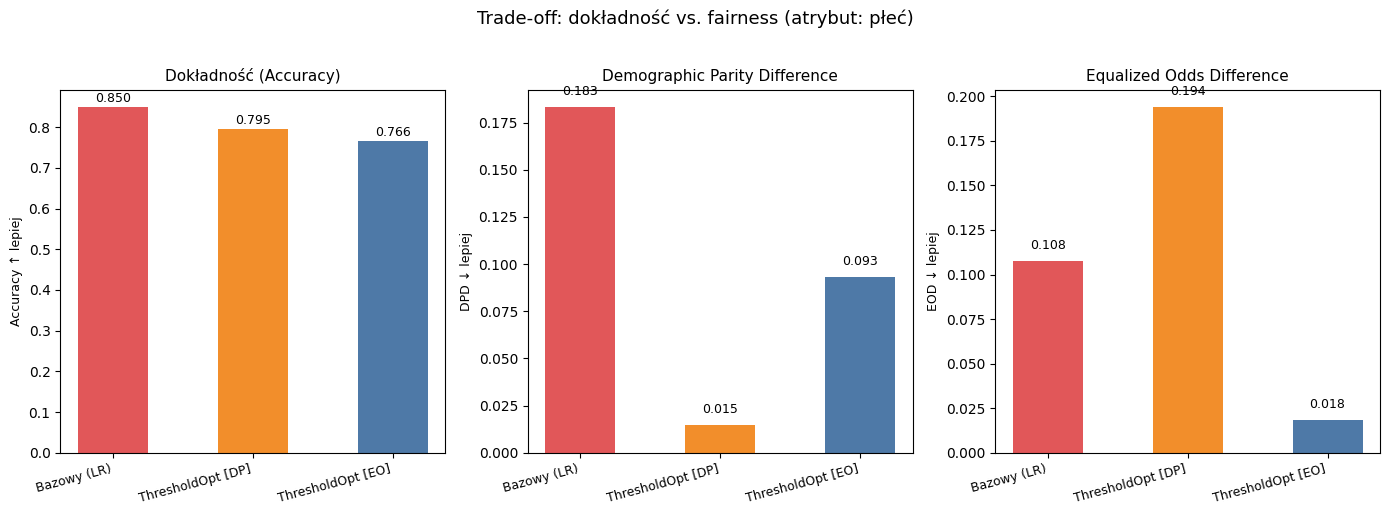

In [8]:
import numpy as np

wyniki = {
    "Model": ["Bazowy (LR)", "ThresholdOpt [DP]", "ThresholdOpt [EO]"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_bazowy),
        accuracy_score(y_test, y_pred_dp_plec),
        accuracy_score(y_test, y_pred_eo_plec),
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, model_bazowy.predict_proba(X_test)[:, 1]),
        None,
        None,
    ],
    "DPD (płeć)": [dpd_plec_baz, dpd_dp_plec, dpd_eo_plec],
    "EOD (płeć)": [eod_plec_baz, eod_dp_plec, eod_eo_plec],
}

df_wyniki = pd.DataFrame(wyniki).set_index("Model")
print(df_wyniki.round(3).to_string())
df_wyniki.round(3).to_csv("../wyniki/porownanie_modeli.csv")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

modele = df_wyniki.index.tolist()
x = np.arange(len(modele))
kolory = ["#e15759", "#f28e2b", "#4e79a7"]

for ax, (kolumna, tytul, opis_y) in zip(axes, [
    ("Accuracy",   "Dokładność (Accuracy)",              "Accuracy ↑ lepiej"),
    ("DPD (płeć)", "Demographic Parity Difference",      "DPD ↓ lepiej"),
    ("EOD (płeć)", "Equalized Odds Difference",          "EOD ↓ lepiej"),
]):
    wartosci = df_wyniki[kolumna].fillna(0).values
    bars = ax.bar(x, wartosci, color=kolory, width=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(modele, rotation=15, ha="right", fontsize=9)
    ax.set_title(tytul, fontsize=11)
    ax.set_ylabel(opis_y, fontsize=9)
    for bar, val in zip(bars, wartosci):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Trade-off: dokładność vs. fairness (atrybut: płeć)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../wyniki/porownanie_modeli.png", dpi=150, bbox_inches="tight")
plt.show()